# 23CSE463 – Quantum Computing
## Worksheet 1: Implementation and Verification of Single-Qubit, Two-Qubit and Three-Qubit Quantum Gates and Circuits Using Qiskit

**Name:** Agneay B Nair  
**Reg. No:** CH.SC.U4CSE24102  
**Ex. No:** 1

**Aim:** To construct and simulate quantum circuits using single-qubit, two-qubit and three-qubit gates in Qiskit, to verify each gate against its matrix and truth table, and to prepare the entangled Bell and GHZ states.

### Setup

In [1]:
# Common setup for all programs in this worksheet
%matplotlib inline
import qiskit, numpy as np, matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

print("Qiskit version:", qiskit.__version__)
sim = AerSimulator()
_seed = 2024                                      # seeds incremented per run -> reproducible counts
np.set_printoptions(precision=3, suppress=True, linewidth=110)
plt.rcParams["figure.dpi"] = 100

def show(fig):
    """display a matplotlib figure (circuit diagram / histogram) and close it"""
    display(fig); plt.close(fig)

def run(qc, shots=1024):
    global _seed
    _seed += 1
    return sim.run(transpile(qc, sim), shots=shots, seed_simulator=_seed).result().get_counts()

def amps(sv, tol=1e-9):
    """print the non-zero amplitudes of a statevector with Qiskit labels (qubit 0 rightmost)"""
    n = sv.num_qubits
    for i, a in enumerate(sv.data):
        if abs(a) > tol:
            print(f"  |{i:0{n}b}> : {a.real:+.3f}{a.imag:+.3f}j   P = {abs(a)**2:.3f}")


Qiskit version: 2.5.2


### Program 1
Apply the X, Y, Z, H, S and T gates, one at a time, to $|0\rangle$ and to $|1\rangle$. Display the resulting statevector and the gate matrix for each, and compare them with the matrices in the theory.

=== X gate ===
Matrix (Operator):
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
  X|0> = [0.+0.j 1.+0.j]
  X|1> = [1.+0.j 0.+0.j]

=== Y gate ===
Matrix (Operator):
 [[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
  Y|0> = [0.+0.j 0.+1.j]
  Y|1> = [0.-1.j 0.+0.j]

=== Z gate ===
Matrix (Operator):
 [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
  Z|0> = [1.+0.j 0.+0.j]
  Z|1> = [ 0.+0.j -1.+0.j]

=== H gate ===
Matrix (Operator):
 [[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
  H|0> = [0.707+0.j 0.707+0.j]
  H|1> = [ 0.707+0.j -0.707+0.j]

=== S gate ===
Matrix (Operator):
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
  S|0> = [1.+0.j 0.+0.j]
  S|1> = [0.+0.j 0.+1.j]

=== T gate ===
Matrix (Operator):
 [[1.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]
  T|0> = [1.+0.j 0.+0.j]
  T|1> = [0.   +0.j    0.707+0.707j]



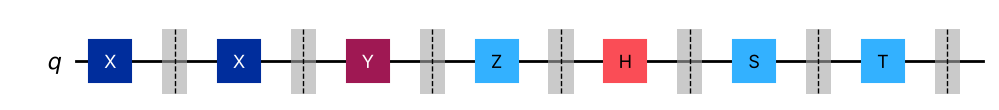

In [2]:
# Program 1: single-qubit gates X, Y, Z, H, S, T on |0> and |1>
gates = ["x", "y", "z", "h", "s", "t"]
for g in gates:
    U = QuantumCircuit(1)
    getattr(U, g)(0)
    print(f"=== {g.upper()} gate ===")
    print("Matrix (Operator):\n", np.round(Operator(U).data, 3))
    for inp in "01":
        qc = QuantumCircuit(1)
        if inp == "1":
            qc.x(0)                       # prepare |1>
        qc.compose(U, inplace=True)
        print(f"  {g.upper()}|{inp}> =", np.round(Statevector(qc).data, 3))
    print()

# circuit diagram: all six gates acting on |1>, separated by barriers
demo = QuantumCircuit(1)
demo.x(0); demo.barrier()
for g in gates:
    getattr(demo, g)(0); demo.barrier()
show(demo.draw("mpl"))

**Inference:** Every Operator matrix matches the theory: X swaps |0> and |1>, Z flips the sign of |1>, Y = iXZ, H creates equal superpositions (±), and S, T add phases i = e^(iπ/2) and e^(iπ/4) to |1> only.

### Program 2
Create a single-qubit circuit with a Hadamard gate, measure it with 1024 shots on the Aer simulator and plot the histogram. Explain why the two counts are close to, but not exactly, 512.

Statevector before measurement: [0.707+0.j 0.707+0.j]


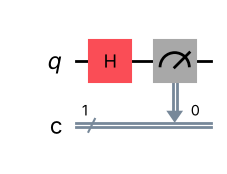

Counts: {'0': 485, '1': 539}
  P(0) = 0.474
  P(1) = 0.526


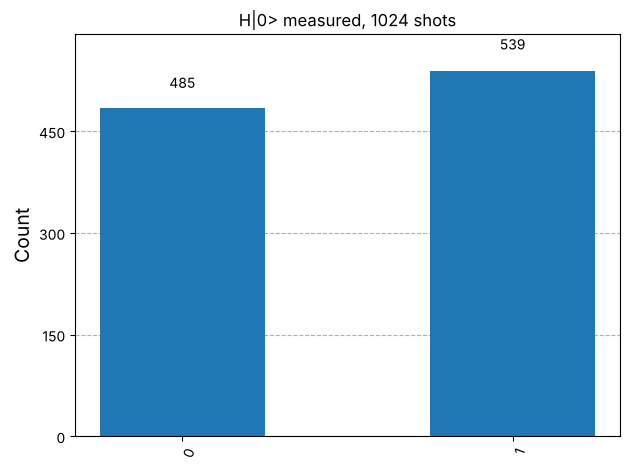

In [3]:
# Program 2: Hadamard + measurement, 1024 shots
qc = QuantumCircuit(1, 1)
qc.h(0)
print("Statevector before measurement:", np.round(Statevector(qc).data, 3))
qc.measure(0, 0)
show(qc.draw("mpl"))
counts = run(qc, 1024)
print("Counts:", counts)
for k in sorted(counts):
    print(f"  P({k}) = {counts[k]/1024:.3f}")
show(plot_histogram(counts, title="H|0> measured, 1024 shots"))

**Inference:** H|0> = (|0>+|1>)/√2, so each outcome has probability 0.5. The counts are close to 512 but not exactly 512 because each shot is an independent random event; the deviation (statistical shot noise ≈ √(1024·0.25) = 16) shrinks relative to the total as the number of shots grows.

### Program 3
Implement the CNOT gate and verify its truth table for all four input states $|00\rangle,|01\rangle,|10\rangle,|11\rangle$. Display its matrix with Operator and explain how it relates to the textbook matrix.

control target -> control target   (measured string is q1q0)
   0      0     ->    0      0


   0      1     ->    0      1
   1      0     ->    1      1


   1      1     ->    1      0


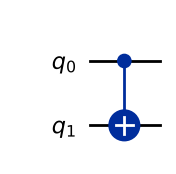


Operator of cx(0,1) in Qiskit's little-endian order:
 [[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]]

After reversing qubit order (control written first):
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]]
Equal to textbook CNOT matrix: True


In [4]:
# Program 3: CNOT truth table. control = qubit 0, target = qubit 1
print("control target -> control target   (measured string is q1q0)")
for c in "01":
    for t in "01":
        qc = QuantumCircuit(2, 2)
        if c == "1": qc.x(0)
        if t == "1": qc.x(1)
        qc.cx(0, 1)
        qc.measure([0, 1], [0, 1])
        out = list(run(qc).keys())[0]          # string q1 q0
        print(f"   {c}      {t}     ->    {out[1]}      {out[0]}")

cnot = QuantumCircuit(2); cnot.cx(0, 1)
show(cnot.draw("mpl"))
print("\nOperator of cx(0,1) in Qiskit's little-endian order:\n", Operator(cnot).data.real)
textbook = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])
print("\nAfter reversing qubit order (control written first):\n", Operator(cnot).reverse_qargs().data.real)
print("Equal to textbook CNOT matrix:", np.allclose(Operator(cnot).reverse_qargs().data, textbook))

**Inference:** The target flips only when the control is 1 (|a,b> -> |a,a⊕b>). Qiskit's matrix has rows in a different order because qubit 0 (the control) is the least-significant bit; after reversing the qubit order it is exactly the textbook CNOT matrix.

### Program 4
Implement the CZ and SWAP gates and verify each on all four basis states. Show, by comparing operators, that a CNOT with a Hadamard gate on the target before and after it is equal to a CZ gate.

=== CZ ===   input (q1q0) -> output state
   |00> -> +1 |00>
   |01> -> +1 |01>
   |10> -> +1 |10>
   |11> -> -1 |11>

=== SWAP ===   input (q1q0) -> output state
   |00> -> +1 |00>
   |01> -> +1 |10>
   |10> -> +1 |01>
   |11> -> +1 |11>



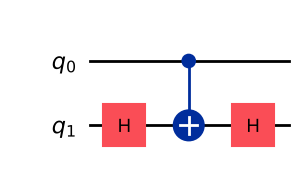

Operator(H.CX.H):
 [[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0. -1.]]
Operator(CZ):
 [[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0. -1.]]
H-CX-H equivalent to CZ: True


In [5]:
# Program 4: CZ and SWAP on all four basis states, and H-CX-H = CZ
for name in ["cz", "swap"]:
    print(f"=== {name.upper()} ===   input (q1q0) -> output state")
    for s in ["00", "01", "10", "11"]:
        qc = QuantumCircuit(2)
        if s[1] == "1": qc.x(0)
        if s[0] == "1": qc.x(1)
        getattr(qc, name)(0, 1)
        sv = Statevector(qc)
        i = int(np.argmax(abs(sv.data)))
        print(f"   |{s}> -> {sv.data[i].real:+.0f} |{i:02b}>")
    print()

lhs = QuantumCircuit(2); lhs.h(1); lhs.cx(0, 1); lhs.h(1)
rhs = QuantumCircuit(2); rhs.cz(0, 1)
show(lhs.draw("mpl"))
print("Operator(H.CX.H):\n", Operator(lhs).data.real.round(3))
print("Operator(CZ):\n", Operator(rhs).data.real)
print("H-CX-H equivalent to CZ:", Operator(lhs).equiv(Operator(rhs)))

**Inference:** CZ leaves 00, 01, 10 unchanged and puts a −1 on |11> only (a phase, invisible to a plain measurement); SWAP exchanges 01 and 10. Since HXH = Z, a CNOT sandwiched by H on the target is exactly a CZ, confirmed by Operator.equiv = True.

### Program 5
Prepare the four Bell states $|\Phi^{+}\rangle,|\Phi^{-}\rangle,|\Psi^{+}\rangle,|\Psi^{-}\rangle$. Display the statevector and the measurement histogram of each.

|Phi+> (input |00>):
  |00> : +0.707+0.000j   P = 0.500
  |11> : +0.707+0.000j   P = 0.500


|Phi-> (input |01>):
  |00> : +0.707+0.000j   P = 0.500
  |11> : -0.707+0.000j   P = 0.500


|Psi+> (input |10>):
  |01> : +0.707+0.000j   P = 0.500
  |10> : +0.707+0.000j   P = 0.500


|Psi-> (input |11>):
  |01> : -0.707+0.000j   P = 0.500
  |10> : +0.707+0.000j   P = 0.500


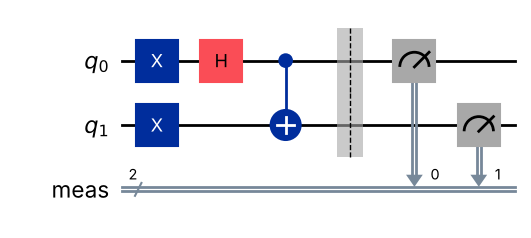

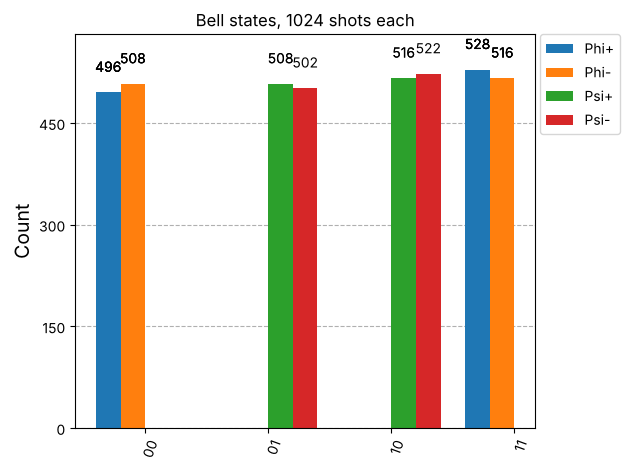

In [6]:
# Program 5: the four Bell states  (input bits b1 b0 -> H on q0, CX(0,1))
names = {"00": "Phi+", "01": "Phi-", "10": "Psi+", "11": "Psi-"}
all_counts = []
for bits, nm in names.items():
    qc = QuantumCircuit(2)
    if bits[1] == "1": qc.x(0)
    if bits[0] == "1": qc.x(1)
    qc.h(0); qc.cx(0, 1)
    print(f"|{nm}> (input |{bits}>):")
    amps(Statevector(qc))
    qc.measure_all()
    all_counts.append(run(qc))
    if nm == "Psi-":
        show(qc.draw("mpl"))
show(plot_histogram(all_counts, legend=list(names.values()), title="Bell states, 1024 shots each"))

**Inference:** Φ± give only 00 and 11 (relative sign + or −), Ψ± give only 01 and 10, each with ≈50% probability. The two qubits are perfectly correlated (Φ) or anti-correlated (Ψ): neither qubit has a state of its own, which is entanglement. The sign of Ψ− appears as (|01>−|10>)/√2 up to a global phase.

### Program 6
Implement the Toffoli (CCX) gate. Verify its truth table for all eight input states and display its 8 × 8 matrix.

q2 q1 q0 (in) -> q2 q1 q0 (out)
   000       ->    000


   001       ->    001


   010       ->    010


   011       ->    111


   100       ->    100
   101       ->    101


   110       ->    110
   111       ->    011


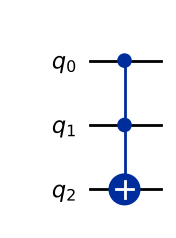


8x8 matrix of CCX (Qiskit order |q2 q1 q0>):
 [[1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0]]


In [7]:
# Program 6: Toffoli (CCX). controls q0, q1 ; target q2
print("q2 q1 q0 (in) -> q2 q1 q0 (out)")
for i in range(8):
    qc = QuantumCircuit(3, 3)
    for b in range(3):
        if (i >> b) & 1: qc.x(b)
    qc.ccx(0, 1, 2)
    qc.measure(range(3), range(3))
    print(f"   {i:03b}       ->    {list(run(qc).keys())[0]}")
tof = QuantumCircuit(3); tof.ccx(0, 1, 2)
show(tof.draw("mpl"))
print("\n8x8 matrix of CCX (Qiskit order |q2 q1 q0>):\n", Operator(tof).data.real.astype(int))

**Inference:** Only inputs with both controls = 1 (011 and 111) have the target flipped (011 <-> 111); all other rows are unchanged. The 8×8 matrix is a permutation matrix that swaps the basis states |011> and |111>, confirming |a,b,c> -> |a,b,c⊕ab>.

### Program 7
Implement the Fredkin (CSWAP) gate. Verify its truth table for all eight input states and state which inputs are changed by the gate.

q2 q1 q0 (in) -> q2 q1 q0 (out)  changed?
   000       ->    000       


   001       ->    001       
   010       ->    010       


   011       ->    101       YES
   100       ->    100       


   101       ->    011       YES
   110       ->    110       


   111       ->    111       


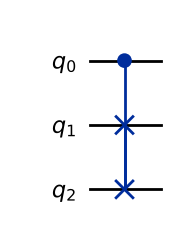

In [8]:
# Program 7: Fredkin (CSWAP). control q0 ; swaps q1 and q2
print("q2 q1 q0 (in) -> q2 q1 q0 (out)  changed?")
fred = QuantumCircuit(3); fred.cswap(0, 1, 2)
for i in range(8):
    qc = QuantumCircuit(3, 3)
    for b in range(3):
        if (i >> b) & 1: qc.x(b)
    qc.compose(fred, inplace=True)
    qc.measure(range(3), range(3))
    out = list(run(qc).keys())[0]
    print(f"   {i:03b}       ->    {out}       {'YES' if out != f'{i:03b}' else ''}")
show(fred.draw("mpl"))

**Inference:** The two target qubits are exchanged only when the control q0 = 1. Only the inputs 011 and 101 are changed (011 -> 101 and 101 -> 011); every other input, including 111 and 001 where the targets are equal, is unchanged. The number of 1s is always conserved.

### Program 8
Prepare the three-qubit GHZ state using one Hadamard gate and two CNOT gates. Display the statevector and the histogram for 1024 shots, and state which outcomes never appear.

GHZ statevector:
  |000> : +0.707+0.000j   P = 0.500
  |111> : +0.707+0.000j   P = 0.500


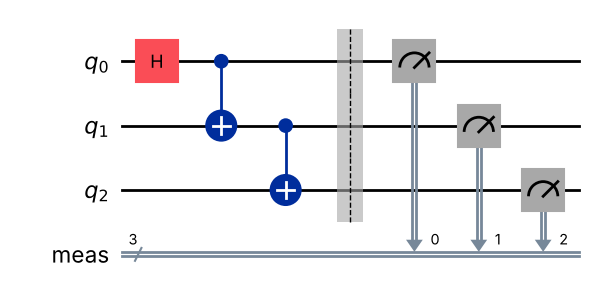

Counts: {'111': 523, '000': 501}
Outcomes that never appear: ['001', '010', '011', '100', '101', '110']


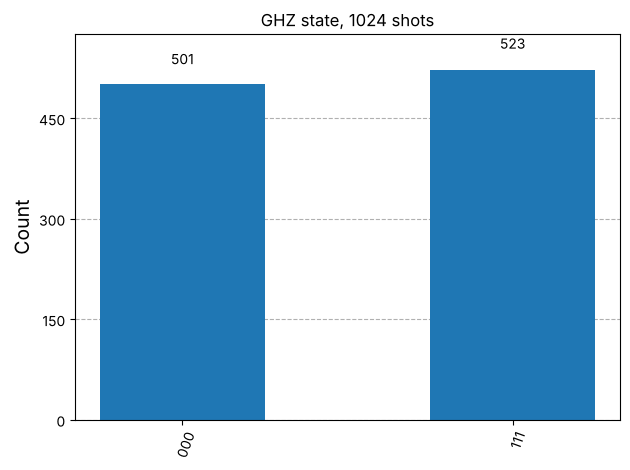

In [9]:
# Program 8: GHZ state
qc = QuantumCircuit(3)
qc.h(0); qc.cx(0, 1); qc.cx(1, 2)
print("GHZ statevector:")
amps(Statevector(qc))
qc.measure_all()
show(qc.draw("mpl"))
counts = run(qc)
print("Counts:", counts)
never = [f"{i:03b}" for i in range(8) if f"{i:03b}" not in counts]
print("Outcomes that never appear:", never)
show(plot_histogram(counts, title="GHZ state, 1024 shots"))

**Inference:** The GHZ state (|000>+|111>)/√2 gives only 000 and 111, each about 50%. The six outcomes 001, 010, 011, 100, 101, 110 never appear: all three qubits are always found equal, a three-qubit entangled state.

### Program 9
Build a reversible half adder on three qubits using one Toffoli gate and one CNOT gate, with the third qubit starting at 0 and holding the carry. Verify the sum and carry for all four inputs.

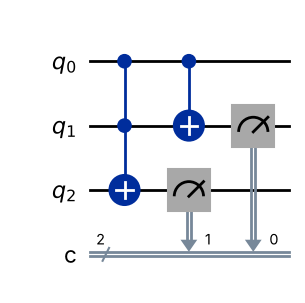

 a b | sum carry
 0 0 |  0    0


 0 1 |  1    0
 1 0 |  1    0


 1 1 |  0    1


In [10]:
# Program 9: reversible half adder. a = q0, b = q1, carry = q2 (starts at 0)
# Toffoli writes carry = a AND b, then CNOT writes sum = a XOR b into q1
ha = QuantumCircuit(3, 2)
ha.ccx(0, 1, 2)
ha.cx(0, 1)
ha.measure(1, 0)   # sum   -> c0
ha.measure(2, 1)   # carry -> c1
show(ha.draw("mpl"))
print(" a b | sum carry")
for a in "01":
    for b in "01":
        qc = QuantumCircuit(3, 2)
        if a == "1": qc.x(0)
        if b == "1": qc.x(1)
        qc.compose(ha, inplace=True)
        out = list(run(qc).keys())[0]      # c1 c0 = carry sum
        print(f" {a} {b} |  {out[1]}    {out[0]}")

**Inference:** The circuit reproduces the half-adder truth table: sum = a⊕b (0,1,1,0) and carry = a·b (0,0,0,1). The Toffoli must act before the CNOT because it needs the original value of b; the circuit is reversible since no information is erased.

### Program 10
Decompose the Toffoli gate into single-qubit and CNOT gates using transpile with the basis gates h, t, tdg and cx. Report the number of CNOT gates and the circuit depth, and confirm with Operator.equiv that the decomposed circuit is the same gate.

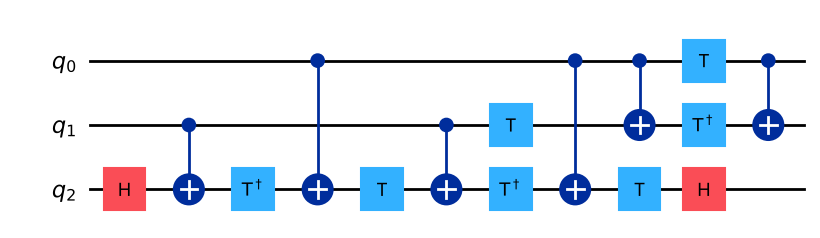

Gate counts: {'cx': 6, 't': 4, 'tdg': 3, 'h': 2}
Number of CNOT gates: 6
Circuit depth: 11
Equivalent to CCX (Operator.equiv): True


In [11]:
# Program 10: decompose Toffoli into {h, t, tdg, cx}
tof = QuantumCircuit(3); tof.ccx(0, 1, 2)
dec = transpile(tof, basis_gates=["h", "t", "tdg", "cx"], optimization_level=0)
show(dec.draw("mpl"))
ops = dict(dec.count_ops())
print("Gate counts:", ops)
print("Number of CNOT gates:", ops.get("cx", 0))
print("Circuit depth:", dec.depth())
print("Equivalent to CCX (Operator.equiv):", Operator(dec).equiv(Operator(tof)))

**Inference:** The Toffoli decomposes into 6 CNOT gates plus H, T and T† gates (15 gates in total) and the decomposed circuit is the same gate (Operator.equiv = True). This is what the hardware actually runs, so a 3-qubit gate costs much more depth than a single gate.

## Viva Q&A

**1. What is a quantum gate, and why must its matrix be unitary?**  
A quantum gate is an operation that changes the state of one or more qubits; on n qubits it is a 2ⁿ×2ⁿ matrix. It must be unitary (U†U = I) so that the total probability stays 1 and the operation is reversible.

**2. What does the Hadamard gate do to the states $|0\rangle$ and $|1\rangle$?**  
H|0> = (|0>+|1>)/√2 = |+> and H|1> = (|0>−|1>)/√2 = |−>: it creates an equal superposition, with a minus sign for |1>. Applying H twice gives back the original state.

**3. State the truth table of the CNOT gate. Which qubit is the control and which is the target?**  
00→00, 01→01, 10→11, 11→10 (control written first). The first qubit is the control and is unchanged; the second is the target and is flipped when the control is 1, i.e. |a,b>→|a,a⊕b>.

**4. How is the CZ gate different from the CNOT gate?**  
CNOT flips the target bit (an X) when the control is 1, which changes the basis state. CZ only multiplies |11> by −1 (a phase); it is symmetric in its two qubits and its effect is invisible to a direct measurement. CZ = (I⊗H)·CNOT·(I⊗H).

**5. What is entanglement? How is a Bell state prepared?**  
Entanglement is a correlation in which the joint state cannot be written as a product of individual qubit states, so neither qubit has a state of its own. A Bell state is prepared by H on the first qubit followed by a CNOT to the second: |00> → (|00>+|11>)/√2.

**6. What does the Toffoli gate do, and why can it reproduce any classical logic circuit?**  
The Toffoli (CCX) flips the target only when both controls are 1: |a,b,c>→|a,b,c⊕ab>. With c = 0 it computes AND, and with c = 1 it computes NAND; since NAND is universal, every classical circuit can be built reversibly from Toffoli gates.

**7. What does the Fredkin gate do?**  
The Fredkin (CSWAP) gate swaps the two target qubits only when the control qubit is 1, otherwise it does nothing. It conserves the number of 1s and is also universal for reversible classical logic.

**8. How is the GHZ state different from a Bell state?**  
A Bell state entangles two qubits; GHZ = (|000>+|111>)/√2 entangles three. In GHZ all three qubits always agree, and measuring any one qubit destroys the entanglement of the remaining two (they collapse to |00> or |11>).

**9. In Qiskit, which qubit is printed as the rightmost bit of a result?**  
Qiskit uses little-endian ordering: qubit 0 is printed as the rightmost bit of a result string, so X on qubit 0 of a two-qubit circuit prints 01.

**10. Why must a three-qubit gate be decomposed before it runs on quantum hardware?**  
Real hardware natively supports only one-qubit and two-qubit gates (and limited connectivity), so a three-qubit gate such as Toffoli must be decomposed (transpiled) into those native gates — the standard Toffoli decomposition uses 6 CNOTs plus H, T and T† gates.

## Result

Single-qubit (X, Y, Z, H, S, T), two-qubit (CNOT, CZ, SWAP) and three-qubit (Toffoli, Fredkin) gates were implemented in Qiskit and verified against their matrices and truth tables using Statevector, Operator and the Aer simulator (1024 shots). The four Bell states and the GHZ state were prepared and their correlated outcomes observed, a reversible half adder was built, and the Toffoli gate was decomposed into 6 CNOTs with H/T/T† gates and verified to be equivalent. Hence the experiment was successfully completed.